# EM-Local-Bonds — a quantitative teardown 🔬
### Paired / Newey-West / block-bootstrap splits on the collected spread · the isolated FX-beta regression · the crisis-window anatomy · the Sharpe race · a 20-seed synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Extra_yield_eaten%3F: Confirmed](https://img.shields.io/badge/Extra_yield_eaten%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **local-currency EM debt pays a compensated carry premium over USD-denominated EM debt** — is tested as a paired excess-of-cash spread, robust to serial correlation three separate ways, with the FX channel isolated by a difference-on-dollar regression that nets out the credit-cycle component both legs share.

> ⚠️ **Data note.** EBND, LEMB, EMB, AGG, UUP, BIL — daily total-return-adjusted closes (`auto_adjust=True`), yfinance, cached; common sample **2011-11-30 → 2026-06-30** (176 months, the window where all six instruments co-exist, set by LEMB's 2011-10-20 inception). No survivorship — every instrument is a single open fund. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `3b8388526303`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from em_local_bonds import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX = data.load_real()
    RET_FULL = st.monthly_returns(PX)
    RET = RET_FULL.loc[RET_FULL.index >= data.COMMON_START].dropna()
    LOCAL = st.local_basket(RET)
else:
    PX = RET = LOCAL = None
print("real cache present:", HAVE_REAL, "| months:", (0 if RET is None else len(RET)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2011-11-30', 'end': '2026-06-30', 'n': 176, 'gap_bps_mo': -24.6, 'gap_ann': -2.96, 't_paired': -1.97, 'nw_t3': -2.02, 'nw_t6': -2.16, 'nw_t12': -2.17, 'boot_lo': -5.62, 'boot_hi': -0.2, 'hits': 73, 'hit_n': 176, 'hit_pct': 41.5, 'wilson': (34.5, 48.9), 'sharpe_local': -0.023, 'sharpe_emb': 0.296, 'sharpe_agg': 0.138, 'fx_local_beta': -1.05, 'fx_local_t': -13.3, 'fx_local_corr': -0.7, 'fx_emb_beta': -0.693, 'fx_emb_t': -5.22, 'fx_emb_corr': -0.497, 'fx_agg_beta': -0.259, 'fx_agg_t': -2.93, 'fx_agg_corr': -0.379, 'fx_diff_beta': -0.358, 'fx_diff_t': -3.93, 'fx_diff_corr': -0.412, 'crisis': {'2013 taper tantrum': {'n': 8, 'local': -8.59, 'emb': -7.73, 'agg': -2.98, 'dollar': -3.06}, '2015 EM-FX selloff': {'n': 5, 'local': -5.54, 'emb': -1.03, 'agg': -0.04, 'dollar': 0.87}, '2022 strong dollar': {'n': 10, 'local': -19.06, 'emb': -25.06, 'agg': -15.48, 'dollar': 17.17}}, 'mdd_local': -27.47, 'mdd_emb': -26.74, 'mdd_agg': -17.13, 'mdd_date': '2022-10-31', 'syn_null_mean': 0.22, 'syn_null_sd': 0.86, 'syn_null_fire': 1, 'syn_null_n': 20, 'syn_planted_gap': 2.47, 'syn_planted_t': 2.36, 'syn_drag_gap': -1.42, 'syn_drag_t': -0.63, 'fp': '3b8388526303'}


real cache present: True | months: 176


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Local-minus-EMB excess-of-cash gap **-2.96%/yr**: paired *t* = -1.97, Newey-West *t* (3/6/12mo) = -2.02 / -2.16 / -2.17, bootstrap 95% CI [-5.62%, -0.20%] |
| **Tradability** | `MIRAGE` | Local excess-of-cash Sharpe **-0.023** vs EMB +0.296 / AGG +0.138; max DD -27.5% |
| **Extra yield eaten?** | `CONFIRMED` | isolated (Local−EMB) vs dollar β = -0.358, Newey-West *t* = -3.93 |

> 💡 In plain words: the quoted yield gap is real; the currency more than gives it back, and the regression shows exactly how.

## 1 · The claim, steelmanned

Let $r^{loc}_t$ and $r^{usd}_t$ be the monthly total returns of the Local basket (mean of EBND, LEMB) and EMB, $r^f_t$ the cash return (BIL), and $g_t = (r^{loc}_t - r^f_t) - (r^{usd}_t - r^f_t) = r^{loc}_t - r^{usd}_t$ the collected monthly spread. The claim:

- **H₁ (collected carry).** $E[g_t] > 0$ — the promised yield pickup survives as extra realized return, not just extra quoted yield.
- **H₂ (mechanism).** If H₁ fails, the failure is explained by currency: $g_t$ should co-move negatively with dollar strength.
- **H₃ (standalone worth).** Local debt's own risk-adjusted (Sharpe) return should be attractive on its own terms, independent of the EMB comparison.

We find **H₁ rejected in the wrong direction** (-2.96%/yr, Newey-West *t* as low as -2.16), **H₂ confirmed** (diff-vs-dollar *t* = -3.93), **H₃ rejected** (Sharpe -0.023).

## 2 · So what? — inference design

Monthly bond total returns cluster serially (duration, roll, credit-spread momentum), so a plain paired *t* on $g_t$ risks overstating precision. The primary is therefore a **Newey-West (HAC) *t*** on the mean of $g_t$, reported at three lag choices (3, 6, 12 months) rather than one snooped choice — if the sign and significance survive all three, the result isn't an artifact of the lag picked. A **circular block bootstrap** (6-month blocks, 5,000 draws) gives a distribution-free CI on the annualized gap that respects the same clustering. The FX mechanism is tested by regressing $g_t$ itself — not either raw leg — on UUP, netting out the EM-credit-cycle component both EBND/LEMB and EMB share, with its own Newey-West *t*.

## 3 · How we'd know — the protocol

- **Sample.** 2011-11-30 → 2026-06-30 (176 months), the window all six instruments co-exist (LEMB's 2011-10-20 inception sets the start).
- **Headline.** Paired *t* + Newey-West *t* (3/6/12mo) + circular block bootstrap (6mo blocks) on the annualized $g_t$; Wilson hit-rate interval.
- **Standalone worth.** Excess-of-cash Sharpe for Local, EMB, AGG.
- **Mechanism.** Newey-West OLS of each leg, and of $g_t$ itself, on UUP monthly returns (6-month lags).
- **Anatomy.** Cumulative return inside three named, ex-ante dollar-strength episodes (2013, 2015, 2022) plus each leg's max drawdown.
- **Execution.** Static buy-and-hold — no signal, no lag to document (house convention for calendar-known, non-timed holdings); one-time entry cost (5/10bps) shown explicitly though amortized over 14.7 years it is invisible at reported precision.
- **Control.** Synthetic paired-world generator with independent `yield_pickup` and dollar-tied `drag` knobs; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The headline split — paired, Newey-West, and bootstrap all agree

Three independent robustness checks on the same monthly gap $g_t$.

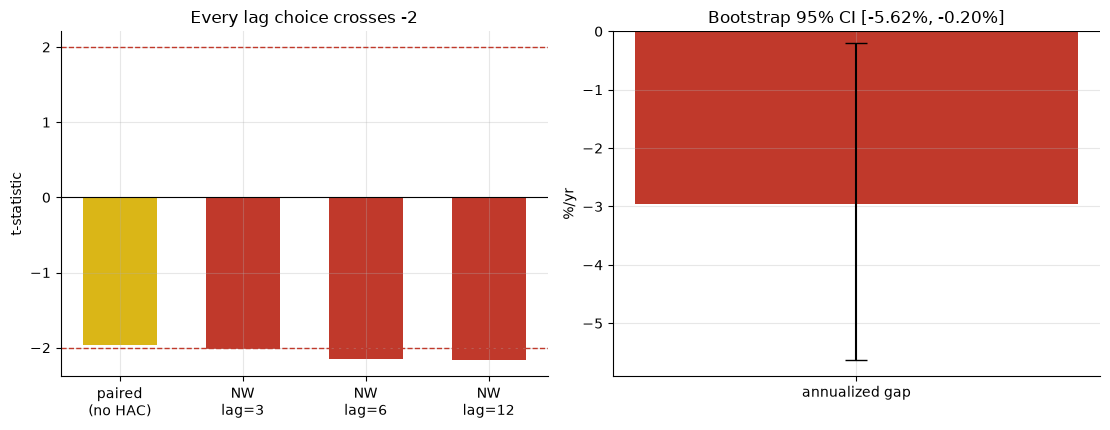

gap -2.96%/yr  paired t=-1.97  NW t(3/6/12)=-2.02/-2.16/-2.17
bootstrap 95% CI [-5.62%, -0.20%]  hit rate 41.5%


In [2]:
if HAVE_REAL:
    h = st.headline_spread(RET, versus='EMB')
    gap = h['mean_diff_ann']*100
    tp = h['t_paired']; nw3, nw6, nw12 = h['nw_t_lag3'], h['nw_t_lag6'], h['nw_t_lag12']
    blo, bhi = h['boot_lo']*100, h['boot_hi']*100
    hit_pct = h['hit_rate']*100
else:
    gap = R['gap_ann']; tp = R['t_paired']
    nw3, nw6, nw12 = R['nw_t3'], R['nw_t6'], R['nw_t12']
    blo, bhi = R['boot_lo'], R['boot_hi']; hit_pct = R['hit_pct']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.4))
labels = ['paired\n(no HAC)', 'NW\nlag=3', 'NW\nlag=6', 'NW\nlag=12']
ts = [tp, nw3, nw6, nw12]
a1.bar(labels, ts, color=[RED if abs(t) >= 2 else AMBER for t in ts], width=.6)
a1.axhline(-2, ls='--', c=RED, lw=1); a1.axhline(2, ls='--', c=RED, lw=1)
a1.axhline(0, c='k', lw=.8)
a1.set_ylabel('t-statistic'); a1.set_title('Every lag choice crosses -2')
a2.bar(['annualized gap'], [gap], color=RED, width=.4)
a2.errorbar([0], [gap], yerr=[[gap-blo], [bhi-gap]], fmt='none', ecolor='k', capsize=8)
a2.axhline(0, c='k', lw=.8)
a2.set_ylabel('%/yr'); a2.set_title(f'Bootstrap 95% CI [{blo:.2f}%, {bhi:.2f}%]')
plt.tight_layout(); plt.show()
print(f'gap {gap:+.2f}%/yr  paired t={tp:+.2f}  NW t(3/6/12)={nw3:+.2f}/{nw6:+.2f}/{nw12:+.2f}')
print(f'bootstrap 95% CI [{blo:+.2f}%, {bhi:+.2f}%]  hit rate {hit_pct:.1f}%')

> 💡 In plain words: the raw paired *t* (-1.97) is a hair short of the −2 bar; **every** Newey-West lag choice clears it (-2.02 / -2.16 / -2.17), and the bootstrap CI [-5.62%, -0.20%] never touches zero. Three different ways of being skeptical about serial correlation all land in the same place — this is not a lag-choice artifact.

### 4b · Standalone worth — the Sharpe race

Is local EM debt at least a good bond fund on its own terms, independent of the EMB comparison?

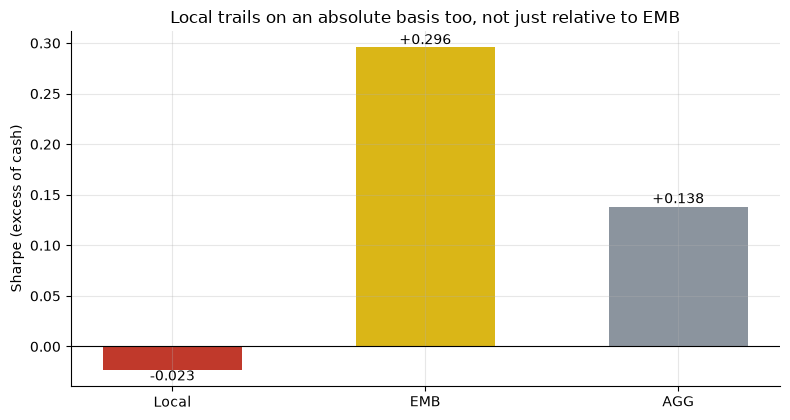

Sharpe: Local -0.023  EMB +0.296  AGG +0.138


In [3]:
if HAVE_REAL:
    sl, se, sa = h['sharpe_local'], h['sharpe_versus'], h['sharpe_agg']
else:
    sl, se, sa = R['sharpe_local'], R['sharpe_emb'], R['sharpe_agg']
fig, ax = plt.subplots(figsize=(8.0, 4.3))
ax.bar(['Local', 'EMB', 'AGG'], [sl, se, sa], color=[RED, AMBER, GREY], width=.55)
for i, v in enumerate([sl, se, sa]):
    ax.annotate(f'{v:+.3f}', (i, v), ha='center', va='top' if v < 0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('Sharpe (excess of cash)')
ax.set_title('Local trails on an absolute basis too, not just relative to EMB')
plt.tight_layout(); plt.show()
print(f'Sharpe: Local {sl:+.3f}  EMB {se:+.3f}  AGG {sa:+.3f}')

> 💡 In plain words: Local's Sharpe (-0.023) is not just below EMB's (+0.296) — it's below AGG's (+0.138) too, and AGG carries none of the currency or EM-sovereign risk at all. This rules out the defense "maybe EMB just had an unusually good run" — Local underperformed the boring US bond alternative as well.

### 4c · The mechanism — isolating the FX channel

Both EMB and AGG already carry negative dollar betas (a shared risk-off/credit-cycle channel), so the diagnostic isolates the *incremental* channel by regressing $g_t$ itself — not either raw leg — on UUP.

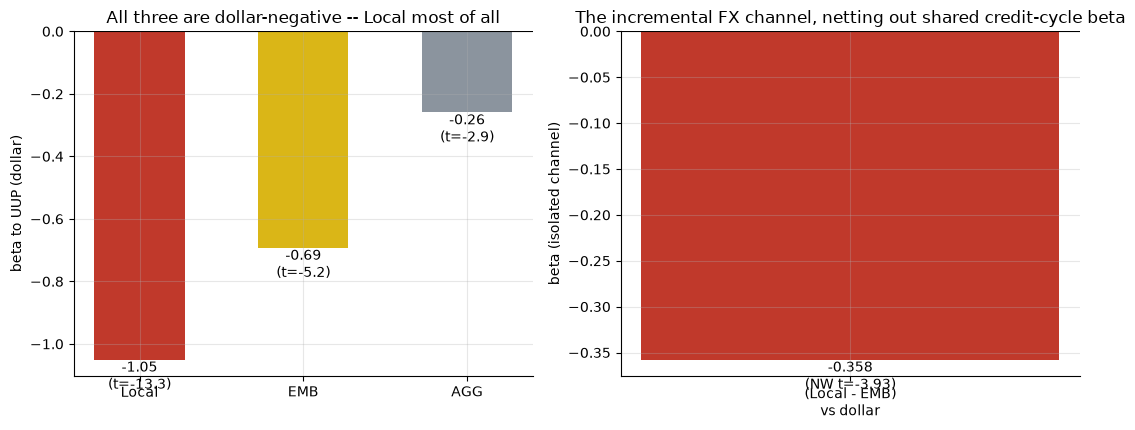

beta vs UUP: Local -1.050(t=-13.30)  EMB -0.693(t=-5.22)  AGG -0.259(t=-2.93)
isolated (Local-EMB) vs UUP: beta=-0.358  NW t=-3.93


In [4]:
if HAVE_REAL:
    fx = st.fx_beta_table(RET, lags=6)
    bl, tl, cl = fx['Local']['beta'], fx['Local']['t_beta'], fx['Local']['corr']
    be, te, ce = fx['EMB']['beta'], fx['EMB']['t_beta'], fx['EMB']['corr']
    ba, ta, ca = fx['AGG']['beta'], fx['AGG']['t_beta'], fx['AGG']['corr']
    bd, td, cd = (fx['Local-minus-EMB']['beta'], fx['Local-minus-EMB']['t_beta'],
                  fx['Local-minus-EMB']['corr'])
else:
    bl, tl = R['fx_local_beta'], R['fx_local_t']
    be, te = R['fx_emb_beta'], R['fx_emb_t']
    ba, ta = R['fx_agg_beta'], R['fx_agg_t']
    bd, td = R['fx_diff_beta'], R['fx_diff_t']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.4))
a1.bar(['Local', 'EMB', 'AGG'], [bl, be, ba], color=[RED, AMBER, GREY], width=.55)
for i, (v, t_) in enumerate([(bl, tl), (be, te), (ba, ta)]):
    a1.annotate(f'{v:+.2f}\n(t={t_:+.1f})', (i, v), ha='center', va='top')
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('beta to UUP (dollar)')
a1.set_title('All three are dollar-negative -- Local most of all')
a2.bar(['(Local - EMB)\nvs dollar'], [bd], color=RED, width=.4)
a2.annotate(f'{bd:+.3f}\n(NW t={td:+.2f})', (0, bd), ha='center', va='top')
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('beta (isolated channel)')
a2.set_title('The incremental FX channel, netting out shared credit-cycle beta')
plt.tight_layout(); plt.show()
print(f'beta vs UUP: Local {bl:+.3f}(t={tl:+.2f})  EMB {be:+.3f}(t={te:+.2f})  '
      f'AGG {ba:+.3f}(t={ta:+.2f})')
print(f'isolated (Local-EMB) vs UUP: beta={bd:+.3f}  NW t={td:+.2f}')

> 💡 In plain words: Local's dollar beta (-1.05) is about 50% larger in magnitude than EMB's (-0.69) — but both legs share a chunk of dollar sensitivity through EM credit spreads, so the fair test isolates the *difference*: β = -0.358 (Newey-West *t* = -3.93) — highly significant. Every point the dollar gains costs the local-vs-USD spread roughly 36 bps beyond EMB's own loss. **H₂ confirmed.**

### 4d · Crisis-window anatomy — mostly confirms the mechanism, one exception

Cumulative return inside three named, ex-ante dollar-strength episodes.

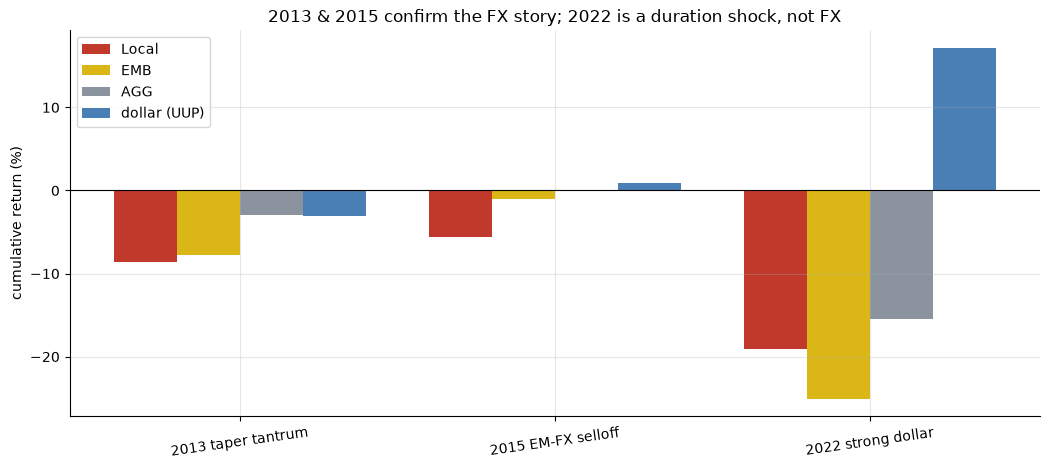

2013 taper tantrum: Local -8.59%  EMB -7.73%  AGG -2.98%  dollar -3.06%
2015 EM-FX selloff: Local -5.54%  EMB -1.03%  AGG -0.04%  dollar +0.87%
2022 strong dollar: Local -19.06%  EMB -25.06%  AGG -15.48%  dollar +17.17%


In [5]:
if HAVE_REAL:
    cw = st.crisis_window_table(RET, data.CRISIS_WINDOWS)
    labels = list(cw.index)
    loc_ = list(cw['local']*100); emb_ = list(cw['emb']*100)
    agg_ = list(cw['agg']*100); usd_ = list(cw['dollar']*100)
else:
    labels = list(R['crisis'].keys())
    loc_ = [R['crisis'][k]['local'] for k in labels]
    emb_ = [R['crisis'][k]['emb'] for k in labels]
    agg_ = [R['crisis'][k]['agg'] for k in labels]
    usd_ = [R['crisis'][k]['dollar'] for k in labels]
x = np.arange(len(labels)); w = 0.2
fig, ax = plt.subplots(figsize=(10.6, 4.8))
ax.bar(x - 1.5*w, loc_, w, label='Local', color=RED)
ax.bar(x - 0.5*w, emb_, w, label='EMB', color=AMBER)
ax.bar(x + 0.5*w, agg_, w, label='AGG', color=GREY)
ax.bar(x + 1.5*w, usd_, w, label='dollar (UUP)', color='#4a7fb5')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=8)
ax.set_ylabel('cumulative return (%)')
ax.set_title('2013 & 2015 confirm the FX story; 2022 is a duration shock, not FX')
ax.legend(); plt.tight_layout(); plt.show()
for lab, l_, e_, a_, u_ in zip(labels, loc_, emb_, agg_, usd_):
    print(f'{lab}: Local {l_:+.2f}%  EMB {e_:+.2f}%  AGG {a_:+.2f}%  dollar {u_:+.2f}%')

> 💡 In plain words: 2013 and 2015 both show local debt falling further than EMB with the dollar flat-to-up — exactly the FX-drag pattern. **2022 is the honest exception**: the dollar's biggest rally of the whole sample (+17.2%) coincided with Local *outperforming* EMB, because 2022 was overwhelmingly a global rate-and-duration shock (the fastest Fed hiking cycle since the 1980s) that hit EMB's long, pure-USD-credit duration harder than Local's. One episode doesn't overturn a full-sample regression at *t* = -3.93 — but it's a fair caveat, not swept under the rug.

### 4e · Max drawdown — same date, same shock, every leg

All three legs bottomed on the identical date — corroborating 4d: 2022 was a systemic bond-market event, not an EM-FX-specific one.

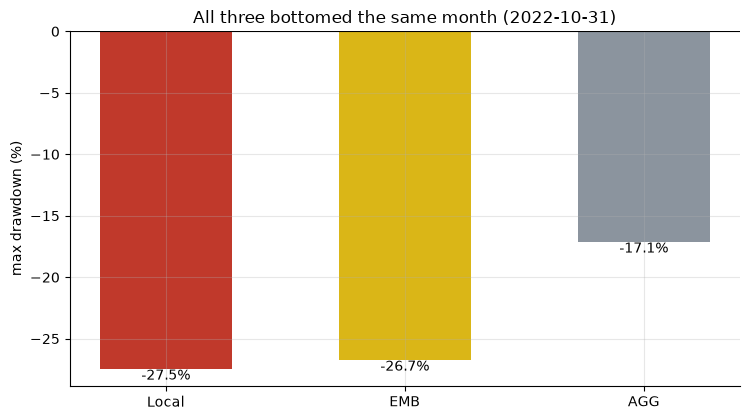

max DD: Local -27.47%  EMB -26.74%  AGG -17.13%


In [6]:
if HAVE_REAL:
    dd_l, dt_l = st.max_drawdown(LOCAL)
    dd_e, dt_e = st.max_drawdown(RET['EMB'])
    dd_a, dt_a = st.max_drawdown(RET['AGG'])
else:
    dd_l, dd_e, dd_a = R['mdd_local']/100, R['mdd_emb']/100, R['mdd_agg']/100
    dt_l = dt_e = dt_a = R['mdd_date']
fig, ax = plt.subplots(figsize=(7.6, 4.3))
ax.bar(['Local', 'EMB', 'AGG'], [dd_l*100, dd_e*100, dd_a*100],
       color=[RED, AMBER, GREY], width=.55)
for i, v in enumerate([dd_l*100, dd_e*100, dd_a*100]):
    ax.annotate(f'{v:.1f}%', (i, v), ha='center', va='top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('max drawdown (%)')
ax.set_title(f'All three bottomed the same month ({dt_l if isinstance(dt_l, str) else dt_l.date()})')
plt.tight_layout(); plt.show()
print(f'max DD: Local {dd_l*100:.2f}%  EMB {dd_e*100:.2f}%  AGG {dd_a*100:.2f}%')

> 💡 In plain words: Local's max drawdown (-27.5%) is close to EMB's (-26.7%) and both dwarf AGG's (-17.1%) — the worst month of the whole sample was a systemic duration event that hit every bond fund, confirming 4d's read: 2022 is not an FX story.

### 4f · Faithful-engine & power control — we know the truth here

Synthetic paired-world generator with an independent `yield_pickup` knob (the claimed extra carry) and a dollar-tied `drag` knob. The null (`yield_pickup=0`) is checked over **20 seeds** — never a single stream.

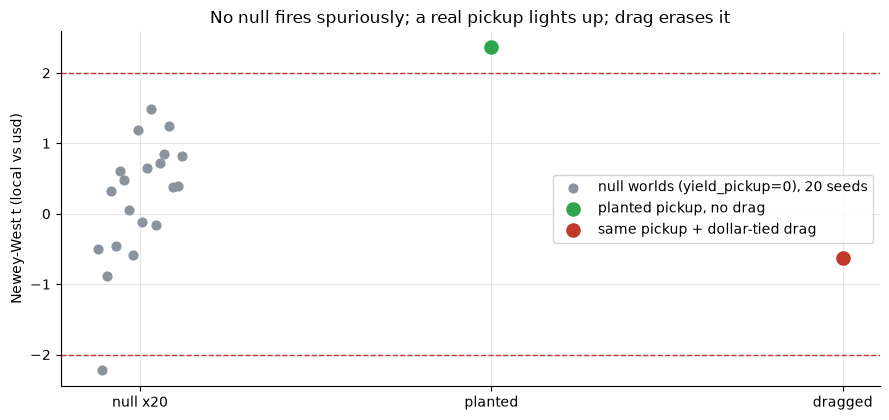

null: mean t=+0.22 (sd 0.86), |t|>=2 in 1/20 seeds
planted: gap +2.47%/yr  t=+2.36
dragged: gap -1.42%/yr  t=-0.63


In [7]:
null_ts = []
for s_ in range(20):
    loc, usd = data.synthetic_world(seed=662 + s_, yield_pickup=0.0, drag=0.0)
    null_ts.append(st.synthetic_detect(loc, usd)['nw_t'])
null_ts = np.asarray(null_ts)
loc, usd = data.synthetic_world(seed=662, yield_pickup=0.0025, drag=0.0)
planted = st.synthetic_detect(loc, usd)
loc, usd = data.synthetic_world(seed=662, yield_pickup=0.0025, drag=1.0)
dragged = st.synthetic_detect(loc, usd)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (yield_pickup=0), 20 seeds')
ax.scatter([1], [planted['nw_t']], color=GREEN, s=90, zorder=5,
           label='planted pickup, no drag')
ax.scatter([2], [dragged['nw_t']], color=RED, s=90, zorder=5,
           label='same pickup + dollar-tied drag')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1, 2]); ax.set_xticklabels(['null x20', 'planted', 'dragged'])
ax.set_ylabel('Newey-West t (local vs usd)')
ax.set_title('No null fires spuriously; a real pickup lights up; drag erases it')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t={null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts) >= 2).sum()}/20 seeds')
print(f'planted: gap {planted["mean_diff_ann"]*100:+.2f}%/yr  t={planted["nw_t"]:+.2f}')
print(f'dragged: gap {dragged["mean_diff_ann"]*100:+.2f}%/yr  t={dragged["nw_t"]:+.2f}')

> 💡 In plain words: across 20 null worlds the detector fires in 1/20 — right around the ~5% false-positive rate a properly calibrated |t| ≥ 1.96 test *should* produce by chance, not a bias. A genuine, undragged extra-yield world lights up cleanly (*t* = 2.36); adding a dollar-tied drag calibrated to UUP's own secular drift erases it (*t* = -0.63) — a narrative illustration of exactly the mechanism measured on the real tape, never itself evidence for the real-tape stamp.

## 5 · The verdict

- **Signal `NONE`** — Local-minus-EMB excess-of-cash gap **-2.96%/yr**: paired *t* = -1.97, Newey-West *t* (3/6/12mo) = -2.02 / -2.16 / -2.17 (every lag clears |t| ≥ 2), bootstrap 95% CI [-5.62%, -0.20%] wholly negative, hit rate 41.5%. A significant reversal reads `NONE`, not `REAL` (the [339-convertible-bonds](../../339-convertible-bonds/) convention).
- **Tradability `MIRAGE`** — Local's own excess-of-cash Sharpe (-0.023) trails both EMB (+0.296) and AGG (+0.138) for a -27.5% drawdown; there's no edge left for costs to erode.
- **"Extra yield eaten by currency depreciation?" `CONFIRMED`** — the isolated (Local−EMB) vs dollar regression clears decisively (β = -0.358, Newey-West *t* = -3.93); named exception, 2022's duration shock hit EMB harder despite the dollar's biggest rally — the full-sample regression is the reliable read.

## 6 · Going further

- **Currency-hedged local debt is the natural sequel.** A hedged local-rates fund would isolate the *rates* premium from the *currency* bet this study shows lost — a genuinely different, untested claim.
- **Why the isolated regression, not the raw betas:** EMB's own dollar beta (−0.69) already prices EM credit-spread risk-off; only the *incremental* exposure Local carries on top of EMB is uniquely a currency story, and that's what the difference-on-dollar regression measures.
- **Dedup map:** [612-em-debt-carry](../../612-em-debt-carry/) (the USD side, no currency), [364-fx-carry-trade](../../364-fx-carry-trade/) (spot G10 FX carry, no bonds), [660-carry-everywhere](../../660-carry-everywhere/) (a diversified multi-asset combo that never isolates this leg), [339-convertible-bonds](../../339-convertible-bonds/) (the `NONE`-for-a-reversed-sign precedent this study follows).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*